## Cyber-Physical Risk Assessment in a Chemical Processing Plant

This notebook presents a **Bayesian Network** for a **chemical processing plant**.  
The purpose is to model how **cyber attacks, sensor failures, controller failures, alarm failures, safety system failures, and operator failures** can interact and eventually lead to **reactor overpressure** and **toxic release**.

The notebook includes:
- Bayesian Network construction
- Conditional Probability Tables (CPTs)
- Model validation
- Professional network visualization
- Inference queries
- Result tables
- Charts
- Final interpretation

##Import Required Libraries

This block imports all the libraries needed for:
- Bayesian Network modeling
- probability tables
- inference
- charts
- network visualization
- result tables

In [ ]:
!pip install pgmpy networkx matplotlib pandas     #required libraries for probabilistic graphical models, # network analysis, visualization, and data manipulation.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 12.7 MB/s eta 0:00:00


In [ ]:
# Import pandas for creating and displaying tables
import pandas as pd

# Import matplotlib for creating charts and plots
import matplotlib.pyplot as plt

# Import networkx for drawing the Bayesian Network graph
import networkx as nx

# Import the Bayesian Network model class from pgmpy
from pgmpy.models import DiscreteBayesianNetwork

# Import TabularCPD for defining conditional probability tables
from pgmpy.factors.discrete import TabularCPD

# Import VariableElimination for exact Bayesian inference
from pgmpy.inference import VariableElimination

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


##Define Helper Functions

This block defines helper functions used throughout the notebook.

These functions help with:
- printing well-formatted section headers
- printing subsection headers
- formatting probabilities in a compact way without too many trailing zeros

In [ ]:
# Define a function to print a major formatted header
def print_header(title: str, width: int = 110) -> None:
    # Print a new line followed by a separator line
    print("\n" + "=" * width)

    # Print the title centered within the given width
    print(title.center(width))

    # Print another separator line
    print("=" * width)


# Define a function to print a smaller formatted subheader
def print_subheader(title: str, width: int = 110) -> None:
    # Print a new line followed by a dashed separator
    print("\n" + "-" * width)

    # Print the title centered within the given width
    print(title.center(width))

    # Print another dashed separator
    print("-" * width)


# Define a function to format probabilities neatly
def prob_str(value: float, decimals: int = 4) -> str:
    # Convert the number to a string with fixed decimals,
    # then remove unnecessary trailing zeros and decimal points
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")

##Define the Bayesian Network Structure

This block creates the Bayesian Network structure using directed edges.

Each edge represents a dependency between variables. For example:
- cyber attack and sensor failure can influence controller failure
- controller failure can influence alarm failure and reactor overpressure
- toxic release depends on reactor overpressure, safety system failure, and operator failure

In [ ]:
# Create a Bayesian Network model with directed edges
model = DiscreteBayesianNetwork([

    # Cyber attack affects the controller
    ("CyberAttack", "ControllerFailure"),

    # Sensor failure also affects the controller
    ("SensorFailure", "ControllerFailure"),

    # Controller failure can cause alarm failure
    ("ControllerFailure", "AlarmFailure"),

    # Controller failure can also lead to reactor overpressure
    ("ControllerFailure", "ReactorOverpressure"),

    # Safety system failure also affects reactor overpressure
    ("SafetySystemFailure", "ReactorOverpressure"),

    # Alarm failure affects operator response
    ("AlarmFailure", "OperatorFailure"),

    # Reactor overpressure also affects operator response
    ("ReactorOverpressure", "OperatorFailure"),

    # Reactor overpressure contributes directly to toxic release
    ("ReactorOverpressure", "ToxicRelease"),

    # Safety system failure contributes directly to toxic release
    ("SafetySystemFailure", "ToxicRelease"),

    # Operator failure contributes directly to toxic release
    ("OperatorFailure", "ToxicRelease"),
])

## Define Conditional Probability Tables (CPTs)

This block defines the probability model for each variable.

### Root Nodes
These are independent prior events:
- CyberAttack
- SensorFailure
- SafetySystemFailure

### Dependent Nodes
These depend on one or more parent variables:
- ControllerFailure
- AlarmFailure
- ReactorOverpressure
- OperatorFailure
- ToxicRelease

These CPTs are the mathematical core of the Bayesian Network.

In [ ]:
# Define prior probability table for CyberAttack
cpd_cyber = TabularCPD(
    # Name of the variable
    variable="CyberAttack",

    # Number of possible states: No / Yes
    variable_card=2,

    # Probability values for No and Yes
    values=[
        [0.93],   # Probability that CyberAttack = No
        [0.07]    # Probability that CyberAttack = Yes
    ],

    # State names for readability
    state_names={"CyberAttack": ["No", "Yes"]}
)


# Define prior probability table for SensorFailure
cpd_sensor = TabularCPD(
    # Name of the variable
    variable="SensorFailure",

    # Number of possible states
    variable_card=2,

    # Probability values
    values=[
        [0.90],   # Probability that SensorFailure = No
        [0.10]    # Probability that SensorFailure = Yes
    ],

    # State names for readability
    state_names={"SensorFailure": ["No", "Yes"]}
)


# Define prior probability table for SafetySystemFailure
cpd_safety = TabularCPD(
    # Name of the variable
    variable="SafetySystemFailure",

    # Number of states
    variable_card=2,

    # Probability values
    values=[
        [0.88],   # Probability that SafetySystemFailure = No
        [0.12]    # Probability that SafetySystemFailure = Yes
    ],

    # State names
    state_names={"SafetySystemFailure": ["No", "Yes"]}
)


# Define CPT for ControllerFailure given CyberAttack and SensorFailure
cpd_controller = TabularCPD(
    # Dependent variable name
    variable="ControllerFailure",

    # Number of states
    variable_card=2,

    # Probability table values
    values=[
        [0.97, 0.75, 0.60, 0.20],   # Probability that ControllerFailure = No
        [0.03, 0.25, 0.40, 0.80]    # Probability that ControllerFailure = Yes
    ],

    # Parent variables
    evidence=["CyberAttack", "SensorFailure"],

    # Number of states for each parent
    evidence_card=[2, 2],

    # State labels for all involved variables
    state_names={
        "ControllerFailure": ["No", "Yes"],
        "CyberAttack": ["No", "Yes"],
        "SensorFailure": ["No", "Yes"]
    }
)


# Define CPT for AlarmFailure given ControllerFailure
cpd_alarm = TabularCPD(
    # Dependent variable name
    variable="AlarmFailure",

    # Number of states
    variable_card=2,

    # Probability values
    values=[
        [0.95, 0.35],   # Probability that AlarmFailure = No
        [0.05, 0.65]    # Probability that AlarmFailure = Yes
    ],

    # Parent variable
    evidence=["ControllerFailure"],

    # Parent cardinality
    evidence_card=[2],

    # State labels
    state_names={
        "AlarmFailure": ["No", "Yes"],
        "ControllerFailure": ["No", "Yes"]
    }
)


# Define CPT for ReactorOverpressure given ControllerFailure and SafetySystemFailure
cpd_overpressure = TabularCPD(
    # Dependent variable
    variable="ReactorOverpressure",

    # Number of states
    variable_card=2,

    # Probability values
    values=[
        [0.99, 0.60, 0.45, 0.05],   # Probability that ReactorOverpressure = No
        [0.01, 0.40, 0.55, 0.95]    # Probability that ReactorOverpressure = Yes
    ],

    # Parent variables
    evidence=["ControllerFailure", "SafetySystemFailure"],

    # Parent cardinalities
    evidence_card=[2, 2],

    # State labels
    state_names={
        "ReactorOverpressure": ["No", "Yes"],
        "ControllerFailure": ["No", "Yes"],
        "SafetySystemFailure": ["No", "Yes"]
    }
)


# Define CPT for OperatorFailure given AlarmFailure and ReactorOverpressure
cpd_operator = TabularCPD(
    # Dependent variable name
    variable="OperatorFailure",

    # Number of states
    variable_card=2,

    # Probability values
    values=[
        [0.98, 0.75, 0.55, 0.20],   # Probability that OperatorFailure = No
        [0.02, 0.25, 0.45, 0.80]    # Probability that OperatorFailure = Yes
    ],

    # Parent variables
    evidence=["AlarmFailure", "ReactorOverpressure"],

    # Parent state counts
    evidence_card=[2, 2],

    # State labels
    state_names={
        "OperatorFailure": ["No", "Yes"],
        "AlarmFailure": ["No", "Yes"],
        "ReactorOverpressure": ["No", "Yes"]
    }
)


# Define CPT for ToxicRelease given ReactorOverpressure, SafetySystemFailure, and OperatorFailure
cpd_release = TabularCPD(
    # Dependent variable name
    variable="ToxicRelease",

    # Number of states
    variable_card=2,

    # Probability values
    values=[
        [0.999, 0.90, 0.88, 0.60, 0.50, 0.30, 0.20, 0.02],  # Probability that ToxicRelease = No
        [0.001, 0.10, 0.12, 0.40, 0.50, 0.70, 0.80, 0.98]  # Probability that ToxicRelease = Yes
    ],

    # Parent variables
    evidence=["ReactorOverpressure", "SafetySystemFailure", "OperatorFailure"],

    # Cardinality of each parent
    evidence_card=[2, 2, 2],

    # State labels
    state_names={
        "ToxicRelease": ["No", "Yes"],
        "ReactorOverpressure": ["No", "Yes"],
        "SafetySystemFailure": ["No", "Yes"],
        "OperatorFailure": ["No", "Yes"]
    }
)

##Add CPTs to the Bayesian Network and Validate the Model

This block attaches all probability tables to the Bayesian Network and checks whether the model is valid.

A valid model means:
- every variable has a defined probability table
- probabilities are correctly normalized
- the dependency structure is internally consistent

In [ ]:
# Add all defined CPTs to the Bayesian Network model
model.add_cpds(
    cpd_cyber,         # Add prior for CyberAttack
    cpd_sensor,        # Add prior for SensorFailure
    cpd_safety,        # Add prior for SafetySystemFailure
    cpd_controller,    # Add CPT for ControllerFailure
    cpd_alarm,         # Add CPT for AlarmFailure
    cpd_overpressure,  # Add CPT for ReactorOverpressure
    cpd_operator,      # Add CPT for OperatorFailure
    cpd_release        # Add CPT for ToxicRelease
)


# VALIDATE MODEL

# Print a validation section header
print_header("MODEL VALIDATION")

# Check whether the Bayesian Network is valid
print(f"Bayesian Network valid : {model.check_model()}")

# Print the number of nodes in the network
print(f"Total nodes            : {len(model.nodes())}")

# Print the number of directed edges in the network
print(f"Total edges            : {len(model.edges())}")


                                               MODEL VALIDATION                                               
Bayesian Network valid : True
Total nodes            : 8
Total edges            : 10


##Display Conditional Probability Tables

This block prints the CPT of each node so that the probabilistic logic of the model can be inspected clearly.

In [ ]:

# Print section header for CPT display
print_header("CONDITIONAL PROBABILITY TABLES")

# Loop through every CPD in the model
for cpd in model.get_cpds():

    # Print a subheader showing the variable name
    print_subheader(f"CPD OF {cpd.variable}")

    # Print the CPT itself
    print(cpd)


                                        CONDITIONAL PROBABILITY TABLES                                        

--------------------------------------------------------------------------------------------------------------
                                              CPD OF CyberAttack                                              
--------------------------------------------------------------------------------------------------------------
+------------------+------+
| CyberAttack(No)  | 0.93 |
+------------------+------+
| CyberAttack(Yes) | 0.07 |
+------------------+------+

--------------------------------------------------------------------------------------------------------------
                                             CPD OF SensorFailure                                             
--------------------------------------------------------------------------------------------------------------
+--------------------+-----+
| SensorFailure(No)  | 0.9 |
+--------------------+

## Professional Aligned Network Visualization

This block draws the Bayesian Network in a structured left-to-right layout.

### Visual arrangement
- **Root causes** on the left
- **Intermediate events** in the center
- **Final consequence** on the right

### Improvements
- manual node positions
- short labels with line breaks
- separate colors for different node categories
- larger figure size for readability
- no overlapping text


                                      PROFESSIONAL NETWORK VISUALIZATION                                      


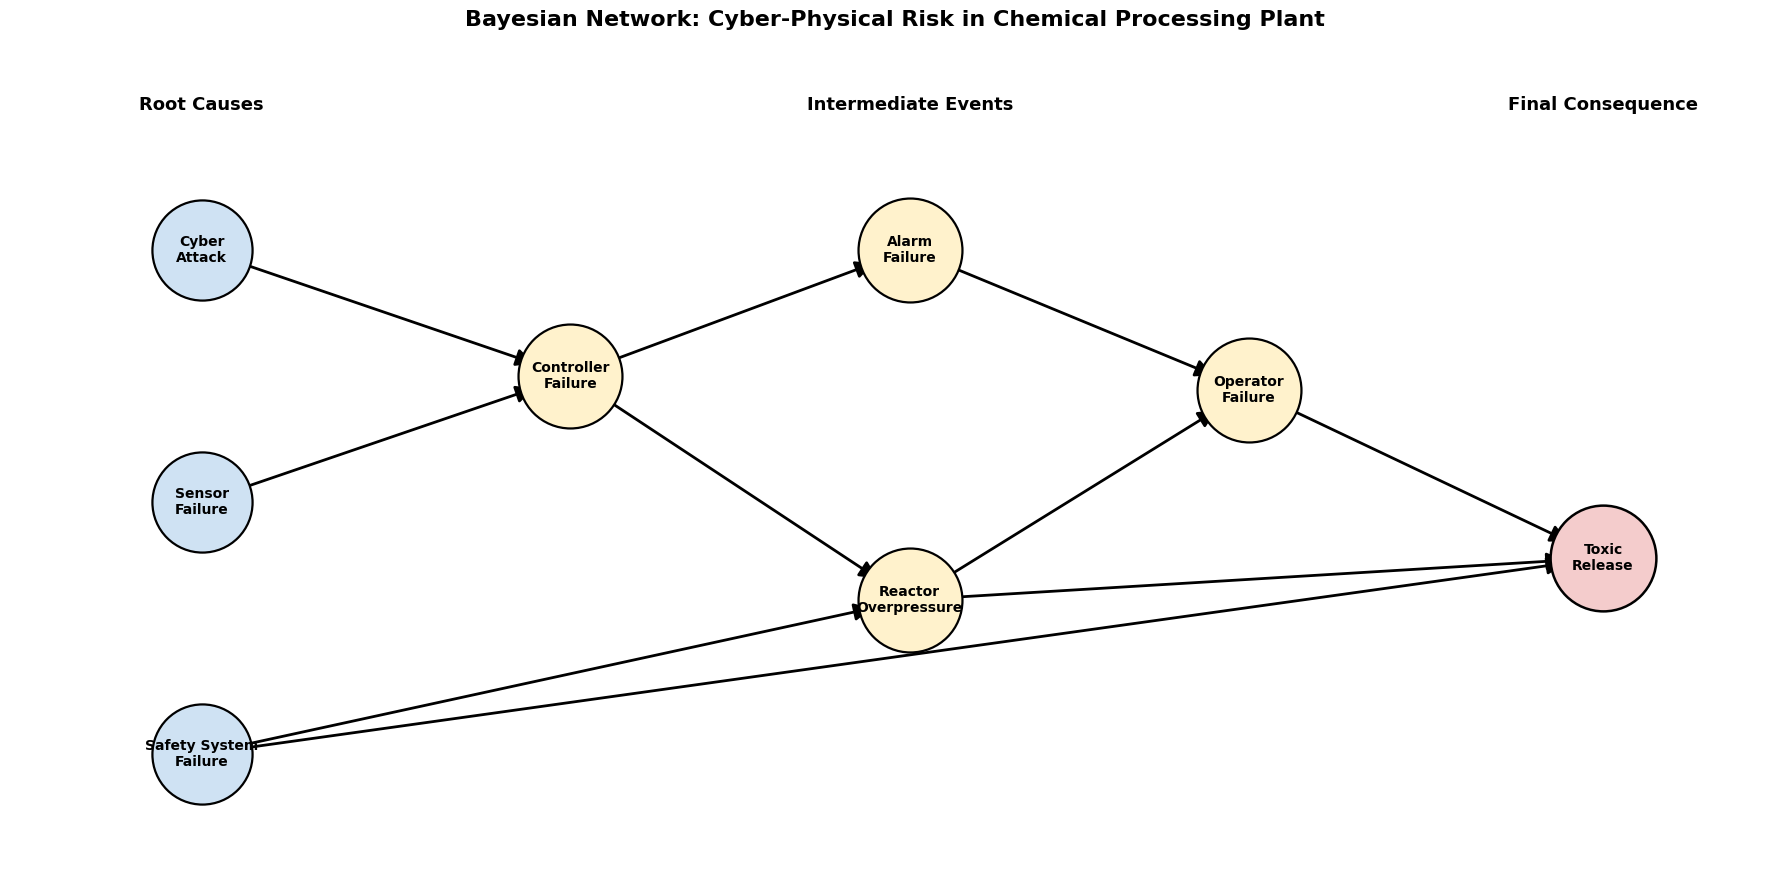

In [ ]:
# Print visualization section header
print_header("PROFESSIONAL NETWORK VISUALIZATION")

# Create a directed graph object using the model edges
G = nx.DiGraph()

# Add all network edges to the graph
G.add_edges_from(model.edges())

# Define short display labels with line breaks to avoid overlap
display_labels = {
    "CyberAttack": "Cyber\nAttack",
    "SensorFailure": "Sensor\nFailure",
    "SafetySystemFailure": "Safety System\nFailure",
    "ControllerFailure": "Controller\nFailure",
    "AlarmFailure": "Alarm\nFailure",
    "ReactorOverpressure": "Reactor\nOverpressure",
    "OperatorFailure": "Operator\nFailure",
    "ToxicRelease": "Toxic\nRelease",
}

# Define manual node positions for a clean left-to-right layout
pos = {
    "CyberAttack": (-3.5,  2.0),            # Root node 1
    "SensorFailure": (-3.5,  0.2),          # Root node 2
    "SafetySystemFailure": (-3.5, -1.6),    # Root node 3

    "ControllerFailure": (-1.0,  1.1),      # Intermediate node
    "AlarmFailure": (1.3,  2.0),            # Intermediate node
    "ReactorOverpressure": (1.3, -0.5),     # Intermediate node
    "OperatorFailure": (3.6,  1.0),         # Intermediate node

    "ToxicRelease": (6.0, -0.2),            # Final consequence
}

# Define node groups for different colors
root_nodes = ["CyberAttack", "SensorFailure", "SafetySystemFailure"]
intermediate_nodes = ["ControllerFailure", "AlarmFailure", "ReactorOverpressure", "OperatorFailure"]
final_nodes = ["ToxicRelease"]

# Create the plotting area with a large figure size
plt.figure(figsize=(18, 9))

# Draw edges first so nodes appear on top of them
nx.draw_networkx_edges(
    G,                         # Graph object
    pos,                       # Manual node positions
    arrows=True,               # Show arrowheads
    arrowsize=26,              # Arrow size
    width=2.0,                 # Edge thickness
    edge_color="black",        # Edge color
    min_source_margin=28,      # Keep arrows away from source text
    min_target_margin=28,      # Keep arrows away from target text
    connectionstyle="arc3,rad=0.0"  # Straight edges
)

# Draw root cause nodes in blue
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=root_nodes,
    node_color="#cfe2f3",
    node_size=5200,
    edgecolors="black",
    linewidths=1.6
)

# Draw intermediate nodes in yellow
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=intermediate_nodes,
    node_color="#fff2cc",
    node_size=5600,
    edgecolors="black",
    linewidths=1.6
)

# Draw final consequence node in red
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=final_nodes,
    node_color="#f4cccc",
    node_size=5800,
    edgecolors="black",
    linewidths=1.8
)

# Draw the text label for each node manually
for node, (x, y) in pos.items():
    plt.text(
        x, y,                     # Text position
        display_labels[node],     # Display label
        fontsize=10,              # Font size
        fontweight="bold",        # Bold text
        ha="center",              # Horizontal alignment
        va="center"               # Vertical alignment
    )

# Add headings for each layer of the network
plt.text(-3.5, 3.0, "Root Causes", fontsize=13, fontweight="bold", ha="center")
plt.text(1.3, 3.0, "Intermediate Events", fontsize=13, fontweight="bold", ha="center")
plt.text(6.0, 3.0, "Final Consequence", fontsize=13, fontweight="bold", ha="center")

# Add a title to the graph
plt.title(
    "Bayesian Network: Cyber-Physical Risk in Chemical Processing Plant",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Turn off axis lines and ticks
plt.axis("off")

# Set x-axis limits for consistent spacing
plt.xlim(-4.8, 7.2)

# Set y-axis limits for consistent spacing
plt.ylim(-2.5, 3.4)

# Automatically adjust layout
plt.tight_layout()

# Display the graph
plt.show()

## Create the Inference Engine

This block creates the Bayesian inference engine using **Variable Elimination**, which will be used to compute posterior probabilities for different risk scenarios.

In [ ]:
# Create an exact inference engine for the Bayesian Network
inference = VariableElimination(model)

## Run Bayesian Inference Queries

This block computes important probabilities such as:
- baseline toxic release probability
- baseline reactor overpressure probability
- toxic release given cyber attack
- toxic release given cyber attack and safety system failure
- controller failure given sensor failure
- toxic release given overpressure and operator failure

In [ ]:
# Print the section header for inference results
print_header("BAYESIAN INFERENCE RESULTS")

# Query the overall probability distribution of ToxicRelease
q1 = inference.query(variables=["ToxicRelease"])

# Query the overall probability distribution of ReactorOverpressure
q2 = inference.query(variables=["ReactorOverpressure"])

# Query ToxicRelease given that a cyber attack has occurred
q3 = inference.query(
    variables=["ToxicRelease"],
    evidence={"CyberAttack": "Yes"}
)

# Query ToxicRelease given cyber attack and safety system failure
q4 = inference.query(
    variables=["ToxicRelease"],
    evidence={"CyberAttack": "Yes", "SafetySystemFailure": "Yes"}
)

# Query ControllerFailure given sensor failure
q5 = inference.query(
    variables=["ControllerFailure"],
    evidence={"SensorFailure": "Yes"}
)

# Query ToxicRelease given reactor overpressure and operator failure
q6 = inference.query(
    variables=["ToxicRelease"],
    evidence={"ReactorOverpressure": "Yes", "OperatorFailure": "Yes"}
)

# Query OperatorFailure given alarm failure
q7 = inference.query(
    variables=["OperatorFailure"],
    evidence={"AlarmFailure": "Yes"}
)

# Query ReactorOverpressure given controller failure
q8 = inference.query(
    variables=["ReactorOverpressure"],
    evidence={"ControllerFailure": "Yes"}
)

# Print each query result clearly
print("1. P(ToxicRelease)")
print(q1)

print("\n2. P(ReactorOverpressure)")
print(q2)

print("\n3. P(ToxicRelease | CyberAttack = Yes)")
print(q3)

print("\n4. P(ToxicRelease | CyberAttack = Yes, SafetySystemFailure = Yes)")
print(q4)

print("\n5. P(ControllerFailure | SensorFailure = Yes)")
print(q5)

print("\n6. P(ToxicRelease | ReactorOverpressure = Yes, OperatorFailure = Yes)")
print(q6)

print("\n7. P(OperatorFailure | AlarmFailure = Yes)")
print(q7)

print("\n8. P(ReactorOverpressure | ControllerFailure = Yes)")
print(q8)


                                          BAYESIAN INFERENCE RESULTS                                          
1. P(ToxicRelease)
+-------------------+---------------------+
| ToxicRelease      |   phi(ToxicRelease) |
+===================+=====================+
| ToxicRelease(No)  |              0.9120 |
+-------------------+---------------------+
| ToxicRelease(Yes) |              0.0880 |
+-------------------+---------------------+

2. P(ReactorOverpressure)
+--------------------------+----------------------------+
| ReactorOverpressure      |   phi(ReactorOverpressure) |
+==========================+============================+
| ReactorOverpressure(No)  |                     0.9004 |
+--------------------------+----------------------------+
| ReactorOverpressure(Yes) |                     0.0996 |
+--------------------------+----------------------------+

3. P(ToxicRelease | CyberAttack = Yes)
+-------------------+---------------------+
| ToxicRelease      |   phi(ToxicRelease) |


## Build a Summary Table of Key Results

This block collects important inference outputs into a structured table and sorts them by probability.

In [ ]:
# Create a list of important queries and their probability of the "Yes" state
results = [
    ["P(ToxicRelease = Yes)", q1.values[1]],
    ["P(ReactorOverpressure = Yes)", q2.values[1]],
    ["P(ToxicRelease = Yes | CyberAttack = Yes)", q3.values[1]],
    ["P(ToxicRelease = Yes | CyberAttack = Yes, SafetySystemFailure = Yes)", q4.values[1]],
    ["P(ControllerFailure = Yes | SensorFailure = Yes)", q5.values[1]],
    ["P(ToxicRelease = Yes | ReactorOverpressure = Yes, OperatorFailure = Yes)", q6.values[1]],
    ["P(OperatorFailure = Yes | AlarmFailure = Yes)", q7.values[1]],
    ["P(ReactorOverpressure = Yes | ControllerFailure = Yes)", q8.values[1]],
]

# Convert the results list into a pandas DataFrame
results_df = pd.DataFrame(results, columns=["Query", "Probability"])

# Ensure the probability column is numeric
results_df["Probability"] = results_df["Probability"].astype(float)

# Add a nicely formatted probability column for display
results_df["Formatted Probability"] = results_df["Probability"].apply(prob_str)

# Sort rows by probability in descending order
results_df = results_df.sort_values(by="Probability", ascending=False).reset_index(drop=True)

# Print a clean table heading
print_header("SUMMARY OF KEY PROBABILITIES")

# Print the query and formatted probability columns
print(results_df[["Query", "Formatted Probability"]].to_string(index=False))


                                         SUMMARY OF KEY PROBABILITIES                                         
                                                                   Query Formatted Probability
P(ToxicRelease = Yes | ReactorOverpressure = Yes, OperatorFailure = Yes)                0.8148
    P(ToxicRelease = Yes | CyberAttack = Yes, SafetySystemFailure = Yes)                0.6192
                  P(ReactorOverpressure = Yes | ControllerFailure = Yes)                 0.598
                           P(OperatorFailure = Yes | AlarmFailure = Yes)                0.5698
                        P(ControllerFailure = Yes | SensorFailure = Yes)                0.2885
                               P(ToxicRelease = Yes | CyberAttack = Yes)                0.2172
                                            P(ReactorOverpressure = Yes)                0.0996
                                                   P(ToxicRelease = Yes)                 0.088


##  Create a Styled Notebook Table

This block displays the results in a more polished notebook-friendly format using pandas styling.

In [ ]:
# Create a styled version of the results table
styled_results = (
    results_df[["Query", "Probability"]]              # Select display columns
    .style                                            # Start styling
    .format({"Probability": lambda x: prob_str(x)})   # Format probabilities compactly
    .set_caption("Key Bayesian Inference Results")    # Add table caption
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
        {"selector": "th", "props": [("background-color", "#d9ead3"), ("color", "black"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "left")]}
    ])
)

# Display the styled table
styled_results

,Query,Probability
0,"P(ToxicRelease = Yes | ReactorOverpressure = Yes, OperatorFailure = Yes)",0.8148
1,"P(ToxicRelease = Yes | CyberAttack = Yes, SafetySystemFailure = Yes)",0.6192
2,P(ReactorOverpressure = Yes | ControllerFailure = Yes),0.598
3,P(OperatorFailure = Yes | AlarmFailure = Yes),0.5698
4,P(ControllerFailure = Yes | SensorFailure = Yes),0.2885
5,P(ToxicRelease = Yes | CyberAttack = Yes),0.2172
6,P(ReactorOverpressure = Yes),0.0996
7,P(ToxicRelease = Yes),0.088


##Visualize Key Probabilities with a Bar Chart

This block plots the major inference probabilities as a bar chart and places compact probability labels above each bar.


                                        BAR CHART OF INFERENCE RESULTS                                        


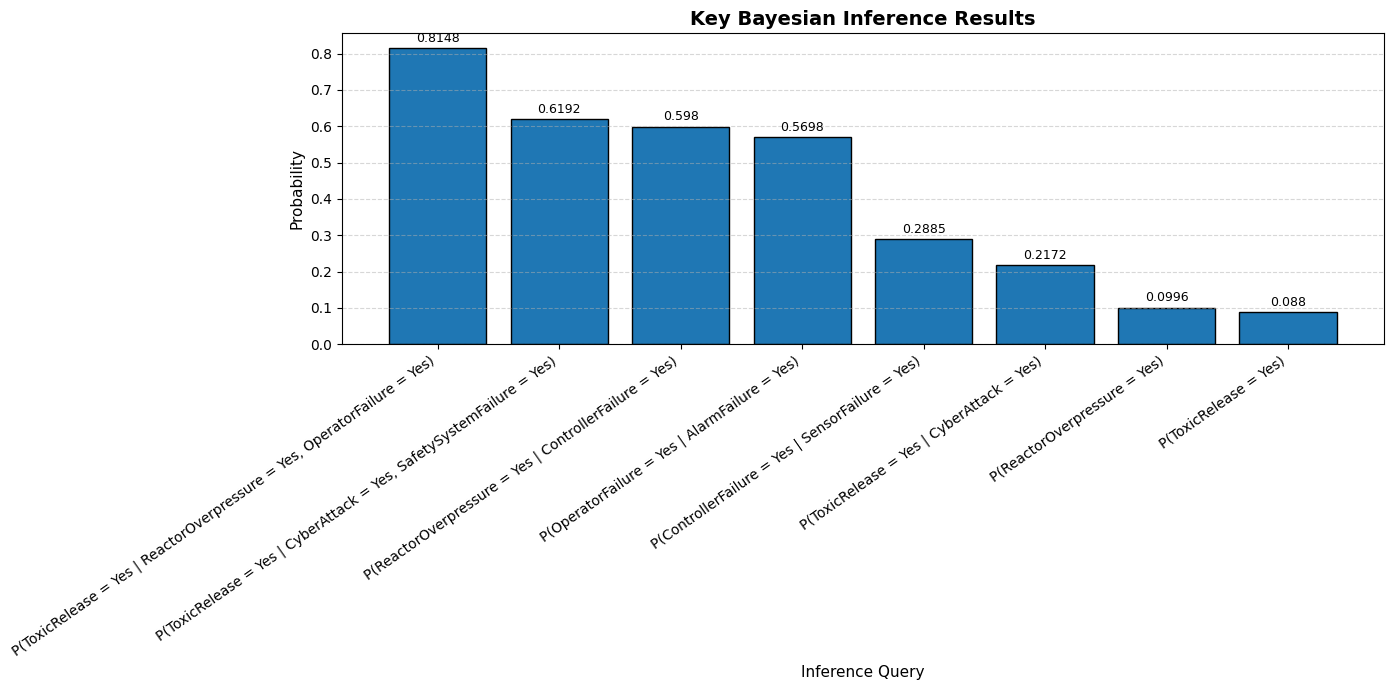

In [ ]:
# Print a section header
print_header("BAR CHART OF INFERENCE RESULTS")

# Create a figure for the bar chart
plt.figure(figsize=(14, 7))

# Plot bars for each query probability
bars = plt.bar(results_df["Query"], results_df["Probability"], edgecolor="black")

# Rotate x-axis labels for readability
plt.xticks(rotation=35, ha="right")

# Add y-axis label
plt.ylabel("Probability", fontsize=11)

# Add x-axis label
plt.xlabel("Inference Query", fontsize=11)

# Add chart title
plt.title("Key Bayesian Inference Results", fontsize=14, fontweight="bold")

# Add light grid lines on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add compact value labels above each bar
for bar, value in zip(bars, results_df["Probability"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # x position at bar center
        bar.get_height() + 0.01,             # y position slightly above bar
        prob_str(value),                     # formatted probability text
        ha="center",                         # center alignment
        va="bottom",                         # bottom alignment
        fontsize=9                           # text size
    )

# Adjust layout automatically
plt.tight_layout()

# Show the bar chart
plt.show()

##Plot Baseline Toxic Release Distribution

This block visualizes the baseline probability of:
- toxic release
- no toxic release

using a pie chart.


                                     BASELINE TOXIC RELEASE DISTRIBUTION                                      


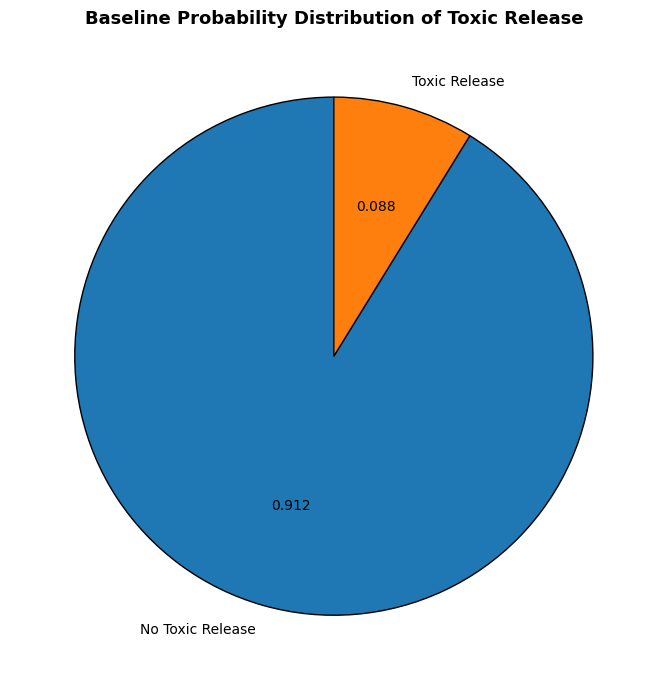

In [ ]:

# Print a section header
print_header("BASELINE TOXIC RELEASE DISTRIBUTION")

# Extract probability of no toxic release
baseline_release_no = q1.values[0]

# Extract probability of toxic release
baseline_release_yes = q1.values[1]

# Create a square figure for the pie chart
plt.figure(figsize=(7, 7))

# Draw the pie chart
plt.pie(
    [baseline_release_no, baseline_release_yes],      # Slice sizes
    labels=["No Toxic Release", "Toxic Release"],     # Slice labels
    autopct=lambda pct: prob_str(pct / 100),          # Compact percentage formatting
    startangle=90,                                    # Start angle for better layout
    wedgeprops={"edgecolor": "black"}                 # Black borders around wedges
)

# Add chart title
plt.title("Baseline Probability Distribution of Toxic Release", fontsize=13, fontweight="bold")

# Adjust layout
plt.tight_layout()

# Show the chart
plt.show()

## Show Root Event Prior Probabilities

This block summarizes the prior probabilities of the root causes and also visualizes them with a bar chart.


                                        ROOT EVENT PRIOR PROBABILITIES                                        
               Node Formatted Probability
        CyberAttack                  0.07
      SensorFailure                   0.1
SafetySystemFailure                  0.12


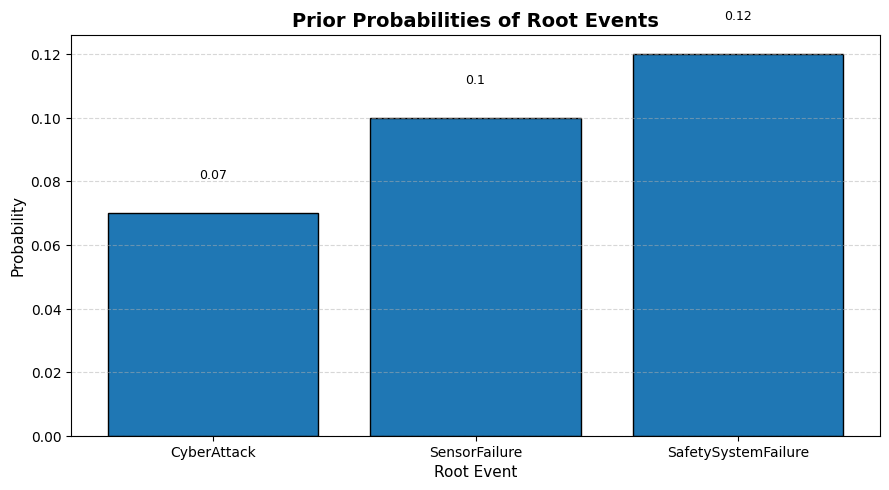

In [ ]:
# Print a section header
print_header("ROOT EVENT PRIOR PROBABILITIES")

# Create a DataFrame for root event prior probabilities
root_df = pd.DataFrame({
    "Node": ["CyberAttack", "SensorFailure", "SafetySystemFailure"],
    "Probability_of_Yes": [0.07, 0.10, 0.12]
})

# Add a compact formatted probability column
root_df["Formatted Probability"] = root_df["Probability_of_Yes"].apply(prob_str)

# Print the table of root prior probabilities
print(root_df[["Node", "Formatted Probability"]].to_string(index=False))

# Create a figure for the root event bar chart
plt.figure(figsize=(9, 5))

# Draw bars
bars = plt.bar(root_df["Node"], root_df["Probability_of_Yes"], edgecolor="black")

# Add y-axis label
plt.ylabel("Probability", fontsize=11)

# Add x-axis label
plt.xlabel("Root Event", fontsize=11)

# Add title
plt.title("Prior Probabilities of Root Events", fontsize=14, fontweight="bold")

# Add light y-axis grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels above bars
for bar, value in zip(bars, root_df["Probability_of_Yes"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # x position
        bar.get_height() + 0.01,             # y position
        prob_str(value),                     # compact formatted value
        ha="center",                         # horizontal alignment
        va="bottom",                         # vertical alignment
        fontsize=9                           # font size
    )

# Adjust layout
plt.tight_layout()

# Show the chart
plt.show()

## Interpret the Results

This block provides short observations about the meaning of the Bayesian inference results.

It highlights:
- which risk scenarios are most significant
- the importance of controller failure
- the importance of safety system failure
- the importance of intermediate hazardous states such as reactor overpressure

In [ ]:
# Print interpretation section header
print_header("INTERPRETATION OF RESULTS")

# Get the highest-probability query from the sorted results table
top_query = results_df.iloc[0]["Query"]

# Get the numeric probability value for the highest-probability query
top_value = results_df.iloc[0]["Probability"]

# Print the top query and its formatted value
print(f"Highest queried probability : {top_query} = {prob_str(top_value)}")

# Print a blank line
print()

# Print interpretation points
print("Observations:")
print("1. Toxic release probability increases significantly when cyber attack and")
print("   safety system failure occur together.")
print("2. Controller failure strongly contributes to reactor overpressure.")
print("3. Alarm failure increases operator failure probability, reducing recovery capability.")
print("4. Reactor overpressure acts as a major intermediate hazardous state.")
print("5. The model demonstrates how cyber, technical, and human failures combine")
print("   to influence the final industrial consequence.")


                                          INTERPRETATION OF RESULTS                                           
Highest queried probability : P(ToxicRelease = Yes | ReactorOverpressure = Yes, OperatorFailure = Yes) = 0.8148

Observations:
1. Toxic release probability increases significantly when cyber attack and
   safety system failure occur together.
2. Controller failure strongly contributes to reactor overpressure.
3. Alarm failure increases operator failure probability, reducing recovery capability.
4. Reactor overpressure acts as a major intermediate hazardous state.
5. The model demonstrates how cyber, technical, and human failures combine
   to influence the final industrial consequence.


## Conclusion

This Bayesian Network provides a probabilistic model of cyber-physical risk in a chemical processing plant. It shows how different root causes and intermediate failures interact and how they may lead to hazardous outcomes such as toxic release.

The model is useful because it:
- represents causal dependencies clearly
- supports probabilistic reasoning under uncertainty
- allows evidence-based inference
- helps identify important contributors to plant risk

This makes Bayesian Networks very useful for industrial safety, cybersecurity, and reliability assessment.

## Final Notebook Output

This final block displays the results dataframe directly in notebook form.

In [ ]:
# Display the full results DataFrame
results_df

,Query,Probability,Formatted Probability
0,P(ToxicRelease = Yes | ReactorOverpressure = Y...,0.814841,0.8148
1,"P(ToxicRelease = Yes | CyberAttack = Yes, Safe...",0.619206,0.6192
2,P(ReactorOverpressure = Yes | ControllerFailur...,0.598000,0.598
3,P(OperatorFailure = Yes | AlarmFailure = Yes),0.569847,0.5698
4,P(ControllerFailure = Yes | SensorFailure = Yes),0.288500,0.2885
5,P(ToxicRelease = Yes | CyberAttack = Yes),0.217230,0.2172
6,P(ReactorOverpressure = Yes),0.099641,0.0996
7,P(ToxicRelease = Yes),0.087970,0.088
